In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os

In [3]:
sns.set_theme(style="whitegrid", font_scale=1.2)
sns.color_palette("husl")

[(0.9677975592919913, 0.44127456009157356, 0.5358103155058701),
 (0.7350228985632719, 0.5952719904750953, 0.1944419133847522),
 (0.3126890019504329, 0.6928754610296064, 0.1923704830330379),
 (0.21044753832183283, 0.6773105080456748, 0.6433941168468681),
 (0.23299120924703914, 0.639586552066035, 0.9260706093977744),
 (0.9082572436765556, 0.40195790729656516, 0.9576909250290225)]

In [4]:
classes = ["MEL", "NV", "BCC", "AK", "BKL", "DF", "VASC", "SCC"]

Show class distribution for each dataset + combined class distribution

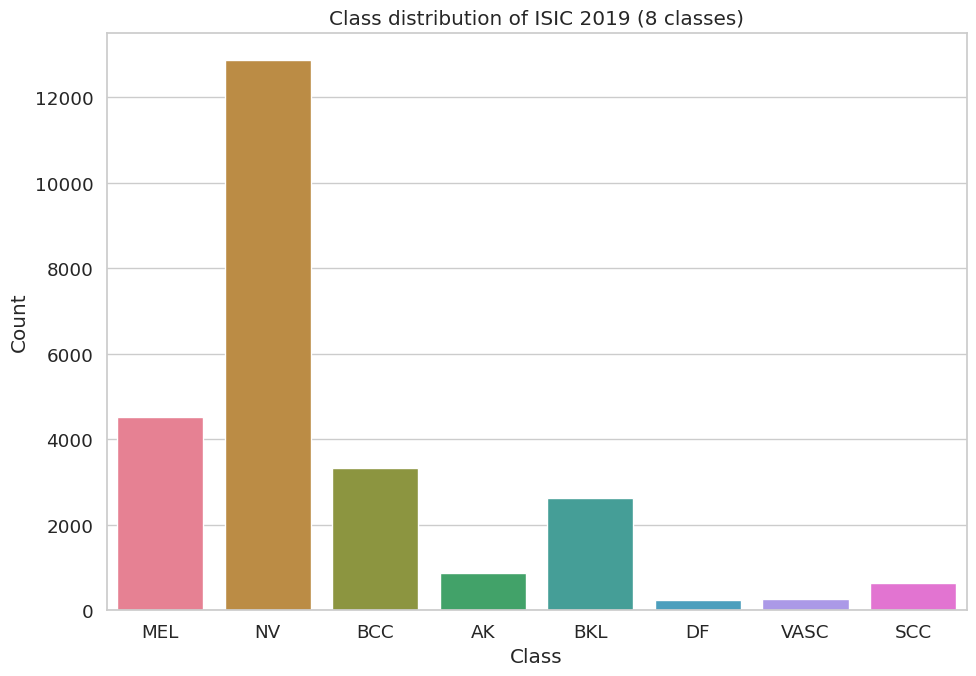

In [5]:
isic_img_labels = pd.read_csv("../../data/ISIC_2019_Training_GroundTruth.csv").drop(columns=["UNK"], errors="ignore")
isic_long = isic_img_labels.melt(id_vars=["image"], var_name="Class", value_name="value")
isic_long = isic_long[isic_long["value"] == 1.0]
isic_counts = isic_long["Class"].value_counts().reindex(classes, fill_value=0).rename_axis("Class").reset_index(name="Count")

plt.figure(figsize=(10, 7))
sns.barplot(data=isic_counts, x="Class", y="Count", hue="Class", palette='husl', legend=False)
plt.title("Class distribution of ISIC 2019 (8 classes)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

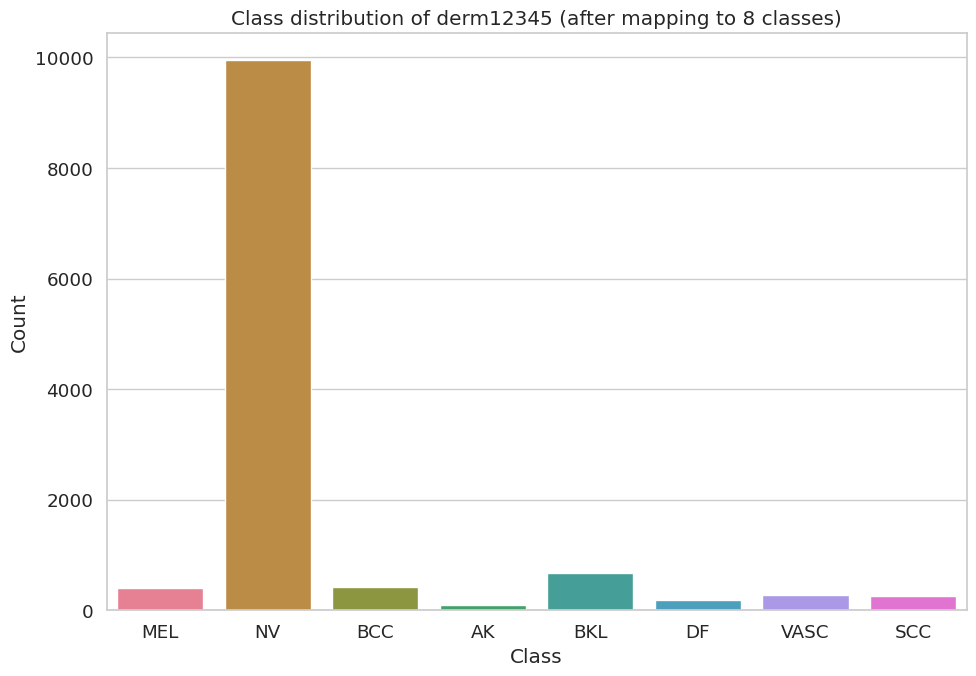

In [6]:
derm_isic_class_mapping_dict = {
    "MEL": ["anm", "alm", "lm", "lmm", "mel"],
    "NV": ["acb","ccb","mcb","cb","bdb","db","ajb","cjb","jb","acd","ccd","cd","ajd","srjd","jd","rd"],
    "BCC": ["bcc"],
    "AK": ["ak", "bd"],
    "BKL": ["sk", "sl", "lk"],
    "DF": ["df"],
    "VASC": ["angk","ha","la","pg","sa"],
    "SCC": ["scc"]
}
leaf_to_isic = {leaf: k for k, vs in derm_isic_class_mapping_dict.items() for leaf in vs}

derm_img_labels = pd.read_csv("../../data/derm12345/derm12345_supplemental.csv")
derm_img_labels["Class"] = derm_img_labels["label"].astype(str).str.strip().map(leaf_to_isic)
derm_counts = derm_img_labels.dropna(subset=["Class"])["Class"].value_counts().reindex(classes, fill_value=0).rename_axis("Class").reset_index(name="Count")

plt.figure(figsize=(10, 7))
sns.barplot(data=derm_counts, x="Class", y="Count", hue="Class", palette='husl', legend=False)
plt.title("Class distribution of derm12345 (after mapping to 8 classes)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

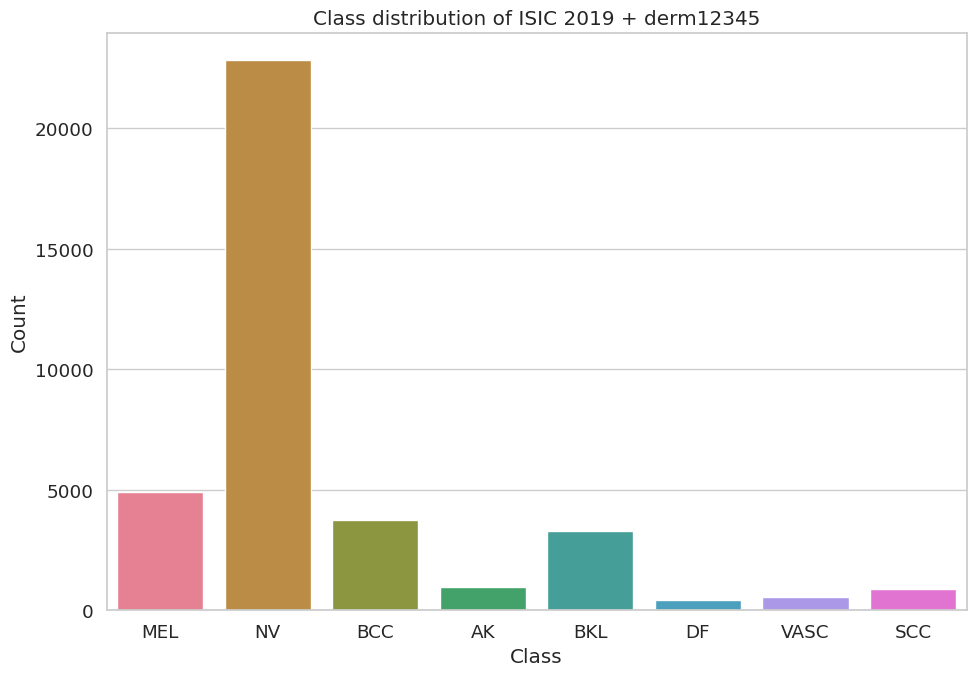

In [7]:
combined_counts = (
    isic_counts.set_index("Class")["Count"]
    .add(derm_counts.set_index("Class")["Count"], fill_value=0)
    .reindex(classes)
    .rename("Count")
    .reset_index()
)

plt.figure(figsize=(10, 7))
sns.barplot(data=combined_counts, x="Class", y="Count", hue="Class", palette='husl', legend=False)
plt.title("Class distribution of ISIC 2019 + derm12345")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
aug_mults = {'AK': 5, 'DF': 5, 'VASC': 5, 'SCC': 5, 'BKL': 3, 'MEL': 2, 'BCC': 2}

isic_df = pd.read_csv("../../data/ISIC_2019_Training_GroundTruth.csv")

if "UNK" in isic_df.columns:
    isic_df = isic_df[isic_df["UNK"] == 0].drop(columns=["UNK"], errors="ignore")

classes = [c for c in isic_df.columns if c != "image"]

isic_train = isic_df.sample(frac=0.80, random_state=42)
isic_rem = isic_df.drop(isic_train.index)
isic_val = isic_rem.sample(frac=0.50, random_state=42)
isic_test = isic_rem.drop(isic_val.index)

def isic_counts_from_ohe(df, classes):
    ohe = df[classes].to_numpy()
    labels_idx = np.argmax(ohe, axis=1)
    label_names = [classes[i] for i in labels_idx]
    return pd.Series(label_names).value_counts().reindex(classes, fill_value=0)

isic_train_counts = isic_counts_from_ohe(isic_train, classes)
isic_val_counts   = isic_counts_from_ohe(isic_val, classes)
isic_test_counts  = isic_counts_from_ohe(isic_test, classes)

leaf_to_isic = {leaf: k for k, vs in derm_isic_class_mapping_dict.items() for leaf in vs}

derm_df = pd.read_csv("../../data/derm12345/derm12345_supplemental.csv")
derm_df["Class"] = derm_df["label"].astype(str).str.strip().map(leaf_to_isic)
derm_df = derm_df.dropna(subset=["Class"])

derm_df = derm_df[derm_df["Class"] != "NV"]

derm_train = derm_df.sample(frac=0.80, random_state=42)
derm_rem = derm_df.drop(derm_train.index)
derm_val = derm_rem.sample(frac=0.50, random_state=42)
derm_test = derm_rem.drop(derm_val.index)

def derm_counts(df, classes):
    return df["Class"].value_counts().reindex(classes, fill_value=0)

derm_train_counts = derm_counts(derm_train, classes)
derm_val_counts   = derm_counts(derm_val, classes)
derm_test_counts  = derm_counts(derm_test, classes)

combined_train = isic_train_counts.add(derm_train_counts, fill_value=0).astype(int)
combined_val   = isic_val_counts.add(derm_val_counts, fill_value=0).astype(int)
combined_test  = isic_test_counts.add(derm_test_counts, fill_value=0).astype(int)

final_train = combined_train.copy()
for cls, mult in aug_mults.items():
    if cls in final_train.index:
        final_train.loc[cls] = int(final_train.loc[cls] * mult)

final_train_df = final_train.rename_axis("Class").reset_index(name="Count")

plt.figure(figsize=(10, 7))
sns.barplot(data=final_train_df, x="Class", y="Count", hue="Class", palette="husl", legend=False)
plt.title(f"Class distribution of ISIC 2019 + derm12345 (training set)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Show training statistics for ISIC 2019 + derm12345

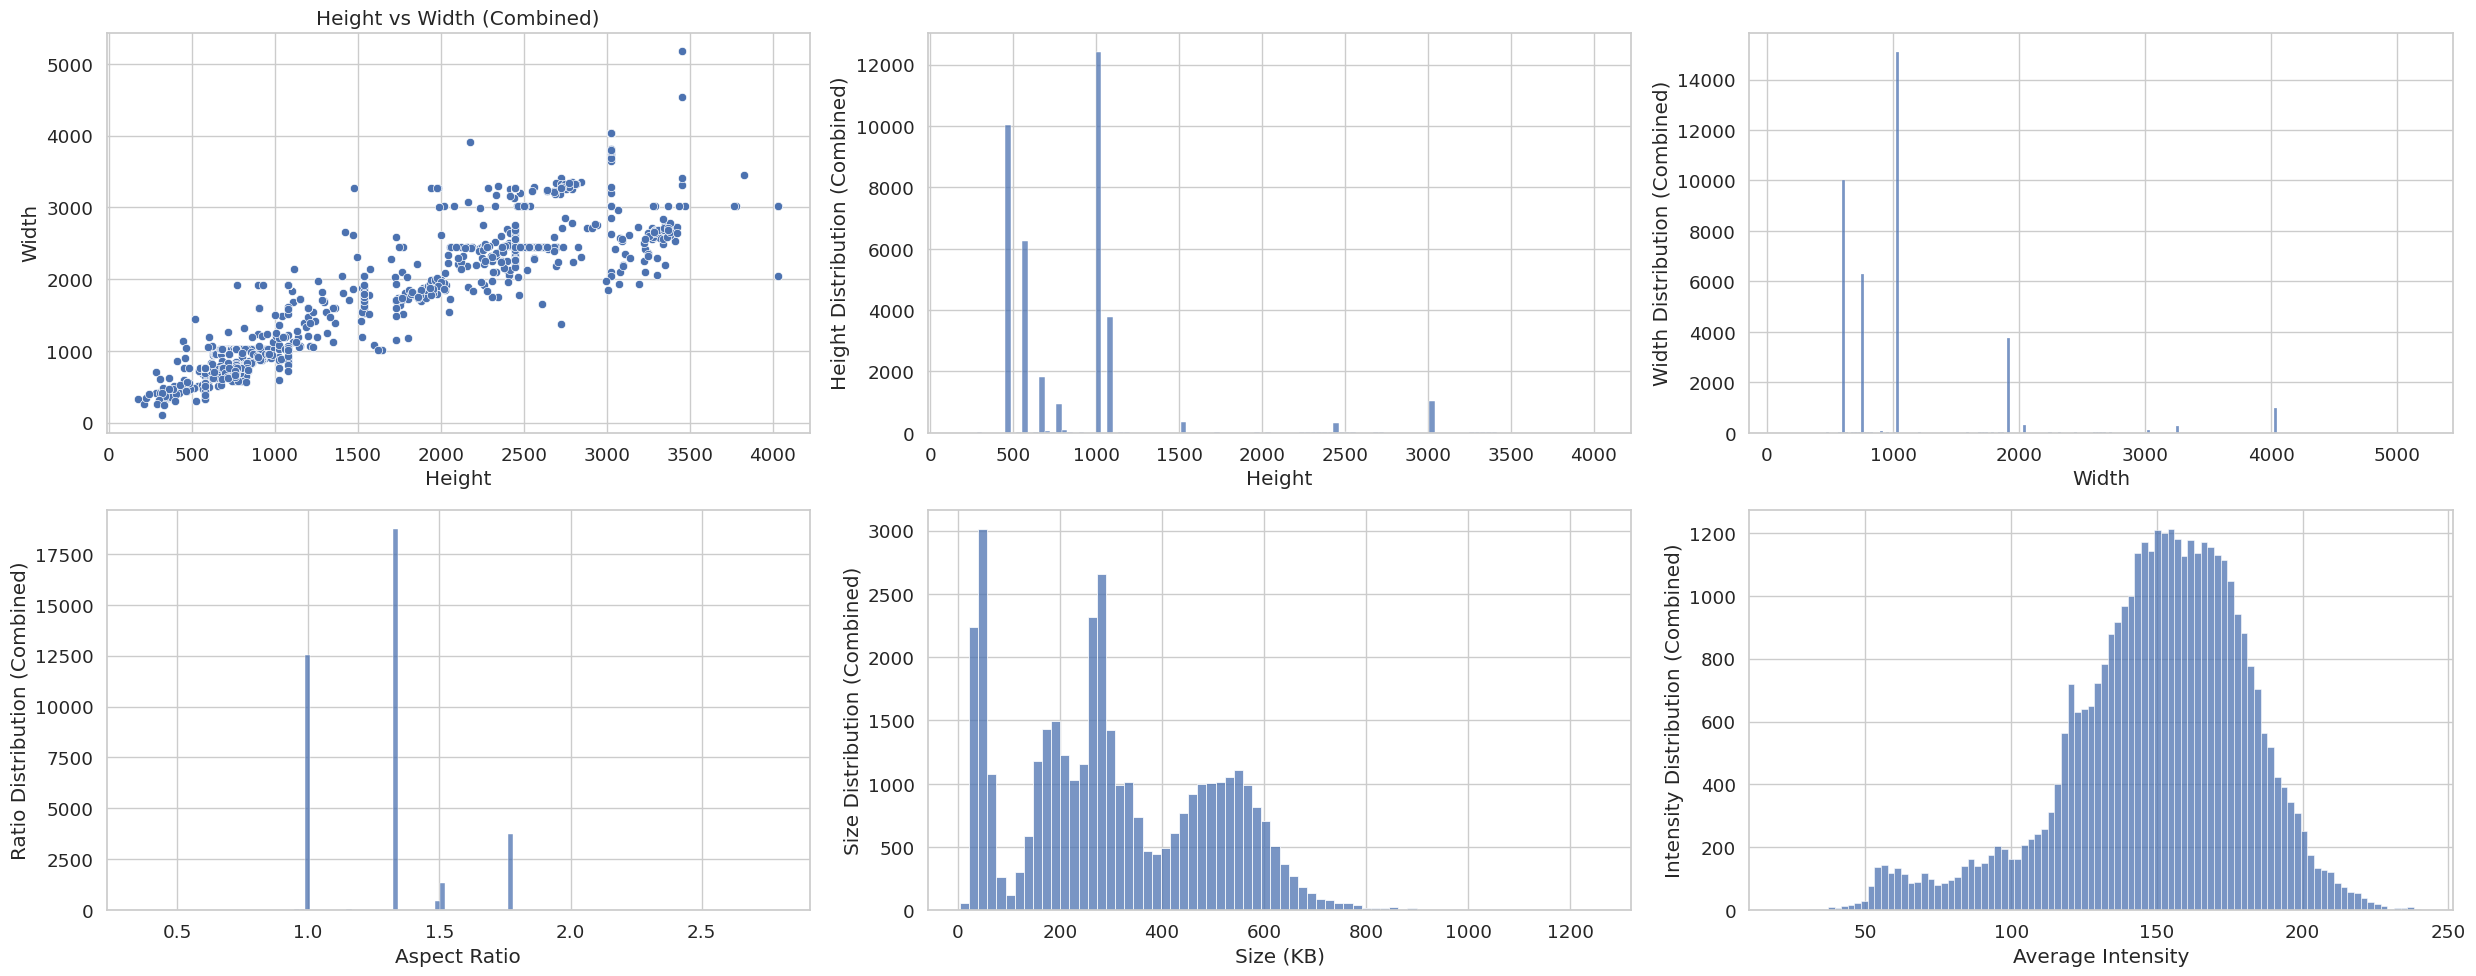

In [8]:
isic_img_labels = pd.read_csv("../../data/ISIC_2019_Training_GroundTruth.csv").drop(columns=["UNK"], errors="ignore")
isic_long = isic_img_labels.melt(id_vars=["image"], var_name="Class", value_name="value")
isic_long = isic_long[isic_long["value"] == 1.0][["image","Class"]]
isic_long[["Height","Width","Aspect Ratio","Size (KB)","Average Intensity"]] = np.nan

for index, row in isic_long.iterrows():
    img_str = row["image"]
    path = f"../../data/ISIC_2019_Training_Input/{img_str}.jpg"
    img = Image.open(path)
    isic_long.loc[index, "Height"] = img.height
    isic_long.loc[index, "Width"] = img.width
    isic_long.loc[index, "Aspect Ratio"] = img.width / img.height
    isic_long.loc[index, "Size (KB)"] = os.stat(path).st_size // 1000
    isic_long.loc[index, "Average Intensity"] = np.mean(np.array(img.convert("L")))

derm_img_labels = pd.read_csv("../../data/derm12345/derm12345_supplemental.csv")
derm_img_labels["Class"] = derm_img_labels["label"].astype(str).str.strip().map(leaf_to_isic)
derm_df = derm_img_labels.dropna(subset=["Class"]).copy()
derm_df["image"] = derm_df["isic_id"].astype(str)
derm_df[["Height","Width","Aspect Ratio","Size (KB)","Average Intensity"]] = np.nan

for index, row in derm_df.iterrows():
    img_str = row["image"]
    path = f"../../data/derm12345/images/{img_str}.jpg"
    img = Image.open(path)
    derm_df.loc[index, "Height"] = img.height
    derm_df.loc[index, "Width"] = img.width
    derm_df.loc[index, "Aspect Ratio"] = img.width / img.height
    derm_df.loc[index, "Size (KB)"] = os.stat(path).st_size // 1000
    derm_df.loc[index, "Average Intensity"] = np.mean(np.array(img.convert("L")))

combined_df = pd.concat(
    [isic_long, derm_df[["image","Class","Height","Width","Aspect Ratio","Size (KB)","Average Intensity"]]],
    ignore_index=True
)

fig, axes = plt.subplots(2, 3, figsize=(25, 10))

sns.scatterplot(data=combined_df, x="Height", y="Width", ax=axes[0][0])
sns.histplot(data=combined_df, x="Height", ax=axes[0][1])
sns.histplot(data=combined_df, x="Width", ax=axes[0][2])
sns.histplot(data=combined_df, x="Aspect Ratio", ax=axes[1][0])
sns.histplot(data=combined_df, x="Size (KB)", ax=axes[1][1])
sns.histplot(data=combined_df, x="Average Intensity", ax=axes[1][2])

axes[0][0].set_title("Height vs Width (Combined)")
axes[0][1].set_ylabel("Height Distribution (Combined)")
axes[0][2].set_ylabel("Width Distribution (Combined)")
axes[1][0].set_ylabel("Ratio Distribution (Combined)")
axes[1][1].set_ylabel("Size Distribution (Combined)")
axes[1][2].set_ylabel("Intensity Distribution (Combined)")

plt.tight_layout()
plt.show()